# Zero-shot Image Classification with OpenAI CLIP and OpenVINO™

Zero-shot image classification is a computer vision task to classify images into one of several classes without any prior training or knowledge of the classes.

![zero-shot-pipeline](https://user-images.githubusercontent.com/29454499/207773481-d77cacf8-6cdc-4765-a31b-a1669476d620.png)

[**image source*](https://huggingface.co/tasks/zero-shot-image-classification)


Zero-shot learning resolves several challenges in image retrieval systems. For example, with the rapid growth of categories on the web, it is challenging to index images based on unseen categories. We can associate unseen categories to images with zero-shot learning by exploiting attributes to model's relationship between visual features and labels.
In this tutorial, we will use the [OpenAI CLIP](https://github.com/openai/CLIP) model to perform zero-shot image classification. Additionally, the notebook demonstrates how to optimize the model using [NNCF](https://github.com/openvinotoolkit/nncf/).


#### Table of contents:

- [Instantiate model](#Instantiate-model)
- [Run PyTorch model inference](#Run-PyTorch-model-inference)
- [Convert model with OpenVINO](#Convert-model-with-OpenVINO)
    - [Convert model using Optimum Intel](#Convert-model-using-Optimum-Intel)
    - [Full quantization](#Full-quantization)
- [Run OpenVINO model](#Run-OpenVINO-model)
    - [Select inference device](#Select-inference-device)
- [Interactive demo](#Interactive-demo)


### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/clip-zero-shot-image-classification/clip-zero-shot-classification.ipynb" />


## Instantiate model
[back to top ⬆️](#Table-of-contents:)

CLIP (Contrastive Language-Image Pre-Training) is a neural network trained on various (image, text) pairs. It can be instructed in natural language to predict the most relevant text snippet, given an image, without directly optimizing for the task.
CLIP uses a [ViT](https://arxiv.org/abs/2010.11929) like transformer to get visual features and a causal language model to get the text features. The text and visual features are then projected into a latent space with identical dimensions. The dot product between the projected image and text features is then used as a similarity score.

![clip](https://raw.githubusercontent.com/openai/CLIP/main/CLIP.png)

[**image_source*](https://github.com/openai/CLIP/blob/main/README.md)

You can find more information about this model in the [research paper](https://arxiv.org/abs/2103.00020), [OpenAI blog](https://openai.com/blog/clip/), [model card](https://github.com/openai/CLIP/blob/main/model-card.md) and GitHub [repository](https://github.com/openai/CLIP).

In this notebook, we will use [openai/clip-vit-base-patch16](https://huggingface.co/openai/clip-vit-base-patch16), available via Hugging Face Transformers, but the same steps are applicable for other CLIP family models.

First, we need to create `CLIPModel` class object and initialize it with model configuration and weights, using `from_pretrained` method. The model will be automatically downloaded from Hugging Face Hub and cached for the next usage.
`CLIPProcessor` class is a wrapper for input data preprocessing. It includes both encoding the text using tokenizer and preparing the images.

In [1]:
%pip install -q --extra-index-url https://download.pytorch.org/whl/cpu "gradio>=4.19" "matplotlib>=3.4" "openvino==2025.3.0" "transformers[torch]==4.57.6" "datasets<4.0.0" "nncf>=2.6.0" "torch==2.8" Pillow "git+https://github.com/huggingface/optimum-intel.git"

from pathlib import Path
import requests

if not Path("notebook_utils.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py",
    )
    open("notebook_utils.py", "w").write(r.text)

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("clip-zero-shot-classification.ipynb")

ERROR: Cannot install openvino==2025.3.0 and optimum-intel==2.3.0.dev0+348272d because these package versions have conflicting dependencies.
ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts


Note: you may need to restart the kernel to use updated packages.


In [2]:
from transformers import CLIPProcessor, CLIPModel

# load pre-trained model
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch16")
# load preprocessor for model input
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch16")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


model.safetensors:  96%|#########6| 577M/599M [00:00<?, ?B/s]

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


def visualize_result(image: Image, labels: list[str], probs: np.ndarray, top: int = 5):
    """
    Utility function for visualization classification results
    params:
      image: input image
      labels: list of classification labels
      probs: model predicted softmaxed probabilities for each label
      top: number of the highest probability results for visualization
    returns:
      None
    """
    plt.figure(figsize=(64, 64))
    top_labels = np.argsort(-probs)[: min(top, probs.shape[0])]
    top_probs = probs[top_labels]
    plt.subplot(8, 8, 1)
    plt.imshow(image)
    plt.axis("off")

    plt.subplot(8, 8, 2)
    y = np.arange(top_probs.shape[-1])
    plt.grid()
    plt.barh(y, top_probs)
    plt.gca().invert_yaxis()
    plt.gca().set_axisbelow(True)
    plt.yticks(y, [labels[index] for index in top_labels])
    plt.xlabel("probability")

## Run PyTorch model inference
[back to top ⬆️](#Table-of-contents:)

To perform classification, define labels and load an image in RGB format. To give the model wider text context and improve guidance, we extend the labels description using the template "This is a photo of a".
Both the list of label descriptions and image should be passed through the processor to obtain a dictionary with input data in the model-specific format. The model predicts an image-text similarity score in raw logits format, which can be normalized to the `[0, 1]` range using the `softmax` function. Then, we select labels with the highest similarity score for the final result.

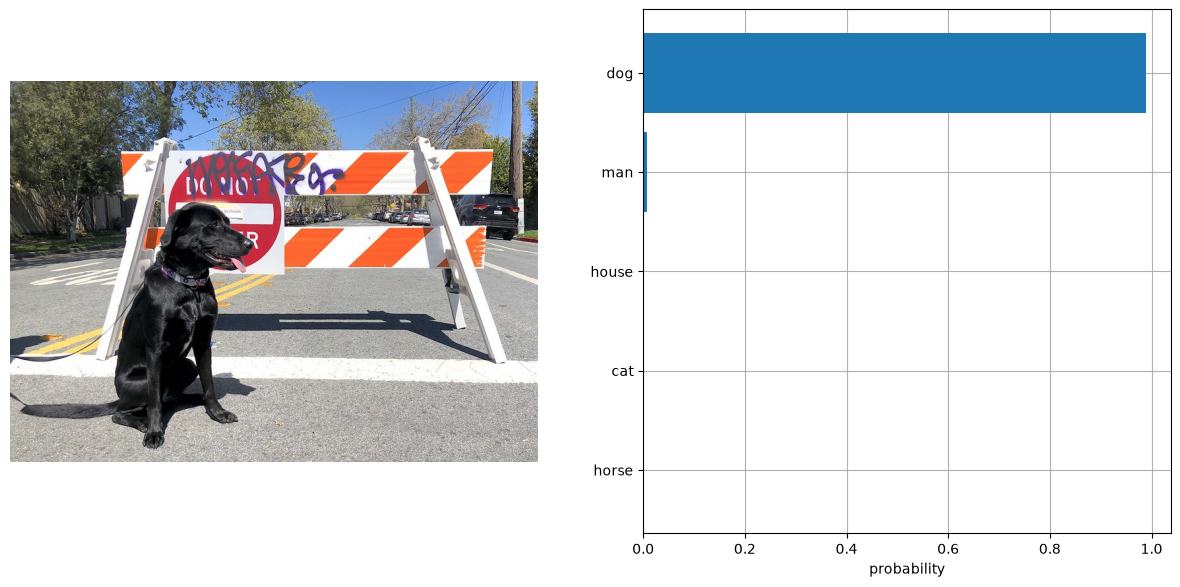

In [4]:
import requests
from pathlib import Path

sample_path = Path("data/coco.jpg")
sample_path.parent.mkdir(parents=True, exist_ok=True)

if not sample_path.exists():
    r = requests.get("https://storage.openvinotoolkit.org/repositories/openvino_notebooks/data/data/image/coco.jpg")

    with sample_path.open("wb") as f:
        f.write(r.content)

image = Image.open(sample_path)

input_labels = [
    "cat",
    "dog",
    "wolf",
    "tiger",
    "man",
    "horse",
    "frog",
    "tree",
    "house",
    "computer",
]
text_descriptions = [f"This is a photo of a {label}" for label in input_labels]

inputs = processor(text=text_descriptions, images=[image], return_tensors="pt", padding=True)

results = model(**inputs)
logits_per_image = results["logits_per_image"]  # this is the image-text similarity score
probs = logits_per_image.softmax(dim=1).detach().numpy()  # we can take the softmax to get the label probabilities
visualize_result(image, input_labels, probs[0])

## Convert model with OpenVINO
[back to top ⬆️](#Table-of-contents:)

Starting from 2023.0 release, OpenVINO supports PyTorch models directly via Model Conversion API. `ov.convert_model` function accepts instance of PyTorch model and example inputs for tracing and returns object of `ov.Model` class, ready to use or save on disk using `ov.save_model` function. 

  
### Convert model using Optimum Intel
[back to top ⬆️](#Table-of-contents:)

For convenience, we will use OpenVINO integration with HuggingFace Optimum. 🤗 [Optimum Intel](https://huggingface.co/docs/optimum/intel/index) is the interface between the 🤗 Transformers and Diffusers libraries and the different tools and libraries provided by Intel to accelerate end-to-end pipelines on Intel architectures.

Among other use cases, Optimum Intel provides a simple interface to optimize your Transformers and Diffusers models, convert them to the OpenVINO Intermediate Representation (IR) format and run inference using OpenVINO Runtime. `optimum-cli` provides command line interface for model conversion and optimization. 

General command format:

```bash
optimum-cli export openvino --model <model_id_or_path> --task <task> <output_dir>
```

where task is task to export the model for, if not specified, the task will be auto-inferred based on the model. You can find a mapping between tasks and model classes in Optimum TaskManager [documentation](https://huggingface.co/docs/optimum/exporters/task_manager). Additionally, you can specify weights compression using `--weight-format` argument with one of following options: `fp32`, `fp16`, `int8` and `int4`. For int8 and int4 [nncf](https://github.com/openvinotoolkit/nncf) will be used weight compression. More details about model export provided in [Optimum Intel documentation](https://huggingface.co/docs/optimum/intel/openvino/export#export-your-model).

### Full quantization
[back to top ⬆️](#Table-of-contents:)

When applying post-training [full quantization](https://huggingface.co/docs/optimum/main/intel/openvino/optimization#full-quantization), both the weights and the activations are quantized. To apply quantization on the activations, an additional calibration step is needed which consists in feeding a calibration_dataset to the network in order to estimate the quantization activations parameters.



In [5]:
import ipywidgets as widgets

to_quantize = widgets.Checkbox(
    value=False,
    description="Quantize",
    disabled=False,
)

to_quantize

Checkbox(value=False, description='Quantize')

In [6]:
from optimum.intel.openvino import OVModelForZeroShotImageClassification, OVQuantizationConfig

model_id = "openai/clip-vit-base-patch16"

model_base_dir = Path(model_id.split("/")[-1])
additional_args = {}

if to_quantize.value:
    model_dir = model_base_dir / "INT8"
    if not model_dir.exists():
        OVModelForZeroShotImageClassification.from_pretrained(
            "openai/clip-vit-base-patch16", quantization_config=OVQuantizationConfig(bits=8, dataset="conceptual_captions")
        ).save_pretrained(model_dir)
else:
    model_dir = model_base_dir / "FP16"
    if not model_dir.exists():
        OVModelForZeroShotImageClassification.from_pretrained("openai/clip-vit-base-patch16").save_pretrained(model_dir)

## Run OpenVINO model
[back to top ⬆️](#Table-of-contents:)

### Select inference device
[back to top ⬆️](#Table-of-contents:)

select device from dropdown list for running inference using OpenVINO

In [7]:
from notebook_utils import device_widget

device = device_widget(exclude=["NPU"])

device

Dropdown(description='Device:', options=('CPU', 'GPU', 'AUTO'), value='CPU')

  DYNAMIC_QUANTIZATION_GROUP_SIZE: 32


  EXECUTION_MODE_HINT: ExecutionMode.PERFORMANCE


  ENABLE_HYPER_THREADING: False


  LOG_LEVEL: Level.NO


  EXECUTION_DEVICES: ['CPU']


...

  PERFORMANCE_HINT_NUM_REQUESTS: 0


  CPU_DENORMALS_OPTIMIZATION: False


  INFERENCE_PRECISION_HINT: <Type: 'bfloat16'>


EXECUTION_DEVICES:


  CPU: AMD RYZEN AI MAX+ PRO 395 w/ Radeon 8060S      


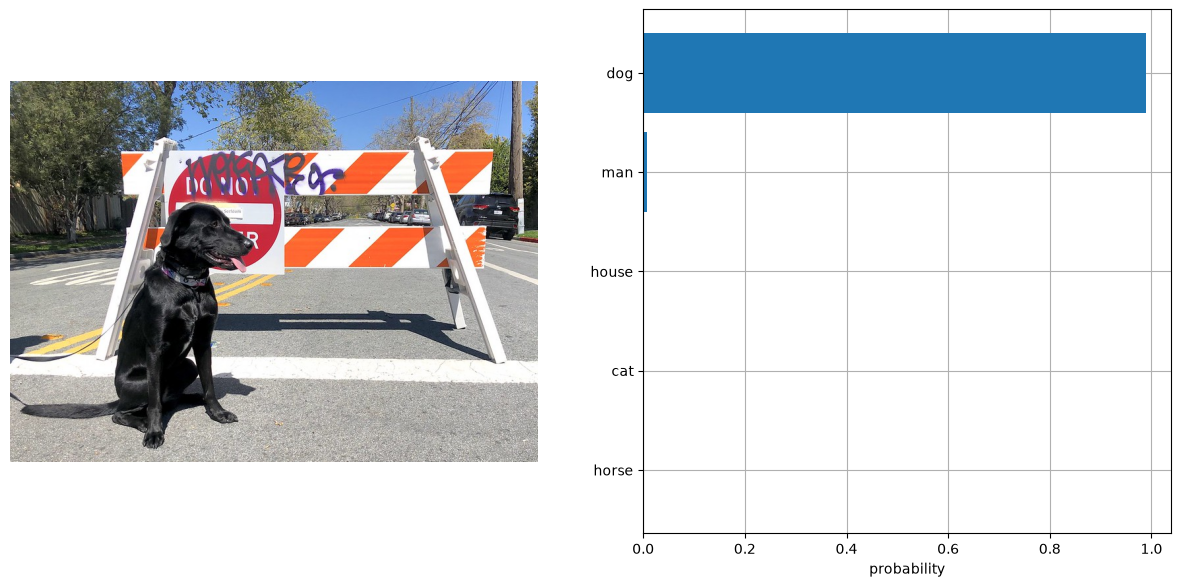

In [8]:
ov_model = OVModelForZeroShotImageClassification.from_pretrained(model_dir, device=device.value)

results = ov_model(**inputs)
logits_per_image = results["logits_per_image"]  # this is the image-text similarity score
probs = logits_per_image.softmax(dim=1).detach().numpy()  # we can take the softmax to get the label probabilities
visualize_result(image, input_labels, probs[0])

Great! Looks like we got the same result.

## Interactive demo
[back to top ⬆️](#Table-of-contents:)

Now, it is your turn! You can provide your own image and comma-separated list of labels for zero-shot classification.

Feel free to upload an image, using the file upload window and type label names into the text field, using comma as the separator (for example, `cat,dog,bird`)

In [9]:
def classify(image, text):
    """Classify image using classes listing.
    Args:
        image (np.ndarray): image that needs to be classified in CHW format.
        text (str): comma-separated list of class labels
    Returns:
        (dict): Mapping between class labels and class probabilities.
    """
    labels = text.split(",")
    text_descriptions = [f"This is a photo of a {label}" for label in labels]
    inputs = processor(text=text_descriptions, images=[image], return_tensors="pt", padding=True)
    results = ov_model(**inputs)
    logits_per_image = results["logits_per_image"]  # this is the image-text similarity score
    probs = logits_per_image.softmax(dim=1).detach().numpy()  # we can take the softmax to get the label probabilities

    return {label: float(prob) for label, prob in zip(labels, probs[0])}